Computing per-pixel statistics...
Per-pixel mean and std computed:
Mean: shape=torch.Size([784]), range=(0.000, 0.547)
Std:  shape=torch.Size([784]), range=(0.000, 0.446)


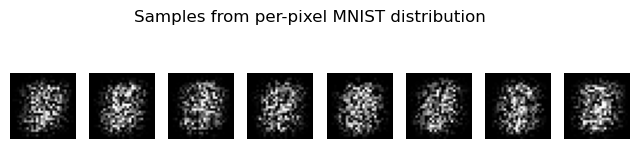

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =====================================
# 1. Load MNIST dataset (flattened)
# =====================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])

train_data = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=512, shuffle=False, num_workers=4)

# =====================================
# 2. Compute per-pixel mean and std
# =====================================
print("Computing per-pixel statistics...")

sum_pixels = torch.zeros(784)
sum_squares = torch.zeros(784)
n_samples = 0

for x, _ in train_loader:
    batch_size = x.size(0)
    sum_pixels += x.sum(dim=0)
    sum_squares += (x ** 2).sum(dim=0)
    n_samples += batch_size

mean_pixels = sum_pixels / n_samples
var_pixels = (sum_squares / n_samples) - mean_pixels**2
std_pixels = torch.sqrt(var_pixels + 1e-8)  # avoid numerical issues

print("Per-pixel mean and std computed:")
print(f"Mean: shape={mean_pixels.shape}, range=({mean_pixels.min():.3f}, {mean_pixels.max():.3f})")
print(f"Std:  shape={std_pixels.shape}, range=({std_pixels.min():.3f}, {std_pixels.max():.3f})")

# =====================================
# 3. Sample new synthetic images
# =====================================
n_samples = 8
samples = torch.randn(n_samples, 784) * std_pixels + mean_pixels  # sample per-pixel Gaussian

# Clip to [0,1] to stay in valid image range
samples = torch.clamp(samples, 0.0, 1.0)

# =====================================
# 4. Visualize the sampled images
# =====================================
plt.figure(figsize=(8, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(samples[i].view(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("Samples from per-pixel MNIST distribution")
plt.show()


In [2]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_receptive_fields(model, n_cols=16, n_rows=8, normalize=True, device=None):
    """
    Visualize the encoder weights (W) of a trained WPropAutoencoder as receptive fields.

    Args:
        model: trained WPropAutoencoder instance
        n_cols: number of columns in the plot grid
        n_rows: number of rows in the plot grid
        normalize: whether to normalize each weight patch to [0, 1]
        device: 'cuda' or 'cpu' (auto-detect if None)
    """
    if device is None:
        device = next(model.parameters()).device

    # Get encoder weights
    W = model.W.detach().to('cpu')  # shape: [hidden_dim, 784]
    n_neurons = min(W.shape[0], n_cols * n_rows)

    plt.figure(figsize=(n_cols, n_rows))
    for i in range(n_neurons):
        w = W[i].view(28, 28)

        if normalize:
            w_min, w_max = w.min(), w.max()
            w = (w - w_min) / (w_max - w_min + 1e-8)

        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(w, cmap="gray", vmin=0, vmax=1)
        plt.axis("off")

    plt.suptitle(f"Encoder Receptive Fields ({model.activation} activation)", fontsize=12)
    plt.tight_layout()
    plt.show()


In [ ]:
visualize_receptive_fields(model, n_rows=10, n_cols=10)


In [3]:
# =====================================
# Multi-Layer Semi-Supervised Autoencoder
# Each layer has lateral connections (L_i)
# Supports both local and backprop learning
# =====================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt


# =====================================
# 1. Model definition
# =====================================
class MultiLayerAutoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[400, 200], num_classes=10,
                 activation="tanh", update_mode="local"):
        super().__init__()
        self.activation = activation.lower()
        self.update_mode = update_mode.lower()
        self.num_classes = num_classes
        self.n_layers = len(hidden_dims)

        # Encoder, decoder, lateral weights
        dims = [input_dim] + hidden_dims
        self.W = nn.ParameterList([
            nn.Parameter(torch.randn(dims[i+1], dims[i]) * 0.01)
            for i in range(self.n_layers)
        ])
        self.V = nn.ParameterList([
            nn.Parameter(torch.randn(dims[i], dims[i+1]) * 0.01)
            for i in range(self.n_layers)
        ])
        self.L = nn.ParameterList([
            nn.Parameter(torch.randn(dims[i+1], dims[i+1]) * 0.01)
            for i in range(self.n_layers)
        ])
        for L in self.L:
            L.data.fill_diagonal_(0.0)

        # Classifier and feedback
        self.W2 = nn.Parameter(torch.randn(num_classes, hidden_dims[-1]) * 0.01)
        self.V2 = nn.Parameter(torch.randn(hidden_dims[-1], num_classes) * 0.01)

    # ---------- Activation and derivative ----------
    def act(self, z):
        if self.activation == "tanh":
            return torch.tanh(z)
        elif self.activation == "relu":
            return F.relu(z)
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")

    def act_deriv(self, h):
        if self.activation == "tanh":
            return 1.0 - h**2
        elif self.activation == "relu":
            return (h > 0).float()

    # ---------- Forward pass ----------
    def forward(self, x):
        h_list, z_list = [], []
        h = x
        for i in range(self.n_layers):
            z = h @ self.W[i].t()
            h = self.act(z)
            z_list.append(z)
            h_list.append(h)

        # Decode only from the *first hidden layer*
        x_hat = torch.sigmoid(h_list[0] @ self.V[0].t())

        # Classifier still uses last hidden layer
        y_logits = h_list[-1] @ self.W2.t()
        y_hat = F.softmax(y_logits, dim=1)

        return h_list, z_list, x_hat, y_hat, y_logits


    # ---------- Local or Backprop update ----------
    def local_update(self, x, h_list, z_list, x_hat, y_hat, y_true, y_logits,
                     beta=1.0, eta_W=1e-3, eta_V=1e-3, eta_W2=1e-3):
        if self.update_mode == "local":
            with torch.no_grad():
                # --- Local Hebbian-like reconstruction updates ---
                e = x - x_hat
                fprime_dec = x_hat * (1.0 - x_hat)
                delta_x = e * fprime_dec
                next_error = delta_x @ self.V[-1]

                for i in reversed(range(self.n_layers)):
                    h = h_list[i]
                    z = z_list[i]
                    fprime_enc = self.act_deriv(h)
                    delta_h = next_error * fprime_enc
                    h_target = h + beta * delta_h

                    # Update encoder and decoder
                    prev_h = x if i == 0 else h_list[i-1]
                    dW = eta_W * ((h_target - h) * fprime_enc).t() @ prev_h
                    dV = eta_V * delta_x.t() @ h

                    self.W[i].data += dW
                    self.V[i].data += dV

                    # Backpropagate "error" to lower layer
                    if i > 0:
                        next_error = delta_h @ self.W[i]

                # --- Classifier local delta rule ---
                y_onehot = F.one_hot(y_true, num_classes=self.num_classes).float()
                delta_y = (y_onehot - y_hat)
                dW2 = eta_W2 * delta_y.t() @ h_list[-1]
                self.W2.data += dW2
            return None

        elif self.update_mode == "backprop":
            # --- Manual backpropagation (classification-driven) ---
            y_true_onehot = F.one_hot(y_true, num_classes=self.num_classes).float()

            # --- Classification error ---
            delta_y = (y_hat - y_true_onehot)
            dW2 = delta_y.t() @ h_list[-1]
            self.W2.data -= eta_W2 * dW2

            # --- Backpropagate classification error into last hidden layer ---
            delta_h = delta_y @ self.W2

            # --- Backward pass through encoder layers ---
            for i in reversed(range(self.n_layers)):
                h = h_list[i]
                z = z_list[i]
                fprime = self.act_deriv(h)
                delta_z = delta_h * fprime

                # Previous layer’s post-activation (or input for layer 0)
                prev_h = x if i == 0 else h_list[i - 1]

                # === Encoder update ===
                dW = delta_z.t() @ prev_h
                self.W[i].data -= eta_W * dW

                # === Decoder update ===
                if i == 0:
                    # Input reconstruction → sigmoid
                    target = x
                    recon = torch.sigmoid(h @ self.V[0].t())
                    fprime_dec = recon * (1.0 - recon)
                else:
                    # Hidden reconstruction → same activation as encoder
                    target = h_list[i - 1]
                    pre_recon = h @ self.V[i].t()
                    recon = self.act(pre_recon)
                    fprime_dec = self.act_deriv(recon)

                # Error and gradient for decoder
                e = recon - target
                delta_dec = e * fprime_dec
                dV = delta_dec.t() @ h
                self.V[i].data -= eta_V * dV

                # --- Propagate error downward for next iteration ---
                if i > 0:
                    delta_h = delta_z @ self.W[i]

            # --- Compute classification loss ---
            loss_cls = F.cross_entropy(y_logits, y_true)
            return loss_cls.item()


    # ---------- Lateral update per layer ----------
    @torch.no_grad()
    def lateral_update(self, h_list, z_list, eta_L=1e-3):
        for i in range(self.n_layers):
            h, z = h_list[i], z_list[i]
            z_pred = h @ self.L[i].t()
            err = z - z_pred
            grad_L = -(err.t() @ h) / h.shape[0]
            self.L[i].data -= eta_L * grad_L
            self.L[i].data.fill_diagonal_(0.0)

    # ---------- Feedback update ----------
    def feedback_update(self, h_last, z_last, y_hat, eta_V2=1e-3):
        z_pred = y_hat @ self.V2.t()
        h_pred = self.act(z_pred)
        err = (h_pred - h_last) * self.act_deriv(z_pred)
        grad_V2 = err.t() @ y_hat / y_hat.shape[0]
        self.V2.data -= eta_V2 * grad_V2


# =====================================
# 2. Load MNIST
# =====================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])
train_data = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)


# =====================================
# 3. Training loop
# =====================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiLayerAutoencoder(hidden_dims=[200],
                              activation="tanh",
                              update_mode="backprop").to(device)

epochs = 30
for epoch in range(epochs):
    total_recon, total_cls, correct, total = 0, 0, 0, 0
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for x, y in progress:
        x, y = x.to(device), y.to(device)

        h_list, z_list, x_hat, y_hat, y_logits = model(x)
        loss_cls = model.local_update(x, h_list, z_list, x_hat, y_hat, y, y_logits)
        model.lateral_update(h_list, z_list)
        model.feedback_update(h_list[-1], z_list[-1], y_hat)

        recon_loss = F.mse_loss(x_hat, x).item()
        total_recon += recon_loss * x.size(0)
        if loss_cls is not None:
            total_cls += loss_cls * x.size(0)
        preds = y_hat.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        progress.set_postfix(recon=recon_loss)

    print(f"Epoch {epoch+1}: Recon={total_recon/len(train_loader.dataset):.6f}, "
          f"Cls={total_cls/len(train_loader.dataset):.6f}, "
          f"Acc={100*correct/total:.2f}%")



Epoch 1/30: 100%|██████████| 469/469 [00:06<00:00, 76.47it/s, recon=0.0477]


Epoch 1: Recon=0.076077, Cls=0.619947, Acc=84.52%


Epoch 2/30: 100%|██████████| 469/469 [00:05<00:00, 79.28it/s, recon=0.0405]


Epoch 2: Recon=0.042602, Cls=0.306584, Acc=91.31%


Epoch 3/30: 100%|██████████| 469/469 [00:05<00:00, 80.28it/s, recon=0.0341]


...

Epoch 28: Recon=0.014495, Cls=0.040507, Acc=99.00%


Epoch 29/30: 100%|██████████| 469/469 [00:05<00:00, 79.97it/s, recon=0.0145]


Epoch 29: Recon=0.014344, Cls=0.038670, Acc=99.06%


Epoch 30/30: 100%|██████████| 469/469 [00:05<00:00, 80.31it/s, recon=0.0126]

Epoch 30: Recon=0.014193, Cls=0.037045, Acc=99.10%


In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_lateral_effect_multilayer_full_reconstruction(model, dataloader, n_samples=8, device=None):
    """
    Visualize how lateral connections change input-space reconstructions
    for each hidden layer in a multi-layer WPropAutoencoder.

    Each hidden layer's activity (and its lateral variant) is decoded
    all the way down to the input space.

    Args:
        model: trained multi-layer WPropAutoencoder
        dataloader: MNIST DataLoader
        n_samples: number of samples to visualize
        device: 'cuda' or 'cpu'
    """
    if device is None:
        device = next(model.parameters()).device

    # === Get input batch ===
    x, _ = next(iter(dataloader))
    x = x.to(device)[:n_samples]

    # === Forward pass through all encoder layers ===
    h_list, z_list = [], []
    h = x
    for i in range(model.n_layers):
        z = h @ model.W[i].t()
        h = model.act(z)
        z_list.append(z)
        h_list.append(h)

    # === Decode each layer all the way to input ===
    normal_recons = []
    lateral_recons = []

    for i in range(model.n_layers):
        h_i = h_list[i]

        # ----- Normal pathway -----
        recon = h_i
        for j in reversed(range(i + 1)):  # decode from layer i → ... → input
            pre = recon @ model.V[j].t()
            if j == 0:
                recon = torch.sigmoid(pre)  # input reconstruction
            else:
                recon = model.act(pre)
        normal_recons.append(recon)

        # ----- Lateral pathway -----
        if hasattr(model, "L"):
            h_lat_pre = h_i @ model.L[i].t()
            h_lat = model.act(h_lat_pre)

            recon_lat = h_lat
            for j in reversed(range(i + 1)):
                pre = recon_lat @ model.V[j].t()
                if j == 0:
                    recon_lat = torch.sigmoid(pre)
                else:
                    recon_lat = model.act(pre)
            lateral_recons.append(recon_lat)
        else:
            raise AttributeError("Model must have lateral weights (L[i])")

    # === Move to CPU ===
    x = x.cpu()
    normal_recons = [r.cpu() for r in normal_recons]
    lateral_recons = [r.cpu() for r in lateral_recons]

    # === Visualization ===
    n = min(n_samples, 8)
    n_layers = model.n_layers
    plt.figure(figsize=(10, 3 * n_layers))

    for layer_idx in range(n_layers):
        for i in range(n):
            # Original
            plt.subplot(n_layers * 3, n, i + 1 + 3 * n * layer_idx)
            plt.imshow(x[i].view(28, 28), cmap='gray', vmin=0, vmax=1)
            plt.axis('off')
            if i == 0:
                plt.ylabel(f"L{layer_idx+1}\nOriginal", fontsize=10)

            # Normal reconstruction (decoded to input)
            plt.subplot(n_layers * 3, n, i + 1 + n + 3 * n * layer_idx)
            plt.imshow(normal_recons[layer_idx][i].view(28, 28),
                       cmap='gray', vmin=0, vmax=1)
            plt.axis('off')
            if i == 0:
                plt.ylabel("Normal", fontsize=10)

            # Lateral reconstruction (decoded to input)
            plt.subplot(n_layers * 3, n, i + 1 + 2 * n + 3 * n * layer_idx)
            plt.imshow(lateral_recons[layer_idx][i].view(28, 28),
                       cmap='gray', vmin=0, vmax=1)
            plt.axis('off')
            if i == 0:
                plt.ylabel("Lateral", fontsize=10)

    plt.suptitle(f"Layer-wise Input Reconstructions with Lateral Effects ({model.activation} activations)",
                 fontsize=12)
    plt.tight_layout()
    plt.show()


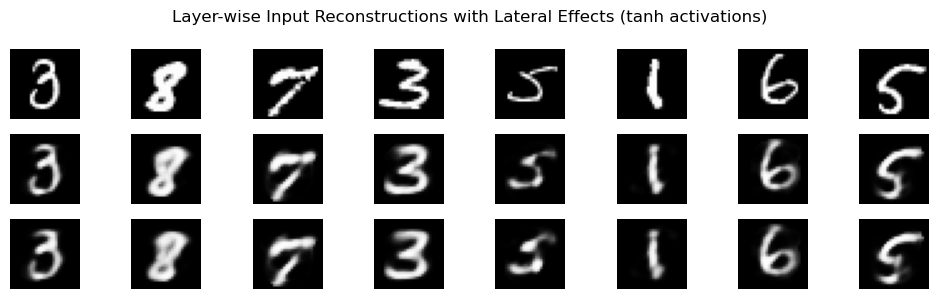

In [5]:
visualize_lateral_effect_multilayer_full_reconstruction(model, train_loader, n_samples=8)


/cluster/raid/home/sschwartz/.conda/envs/DFC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/cluster/raid/home/sschwartz/.conda/envs/DFC/lib/python3.10/site-packages/umap/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Loading MNIST: 100%|██████████| 60000/60000 [00:05<00:00, 10433.27it/s]


Data shape: torch.Size([60000, 784]), Labels shape: torch.Size([60000])


/cluster/raid/home/sschwartz/.conda/envs/DFC/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/cluster/raid/home/sschwartz/.conda/envs/DFC/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP embedding shape: (60000, 2)


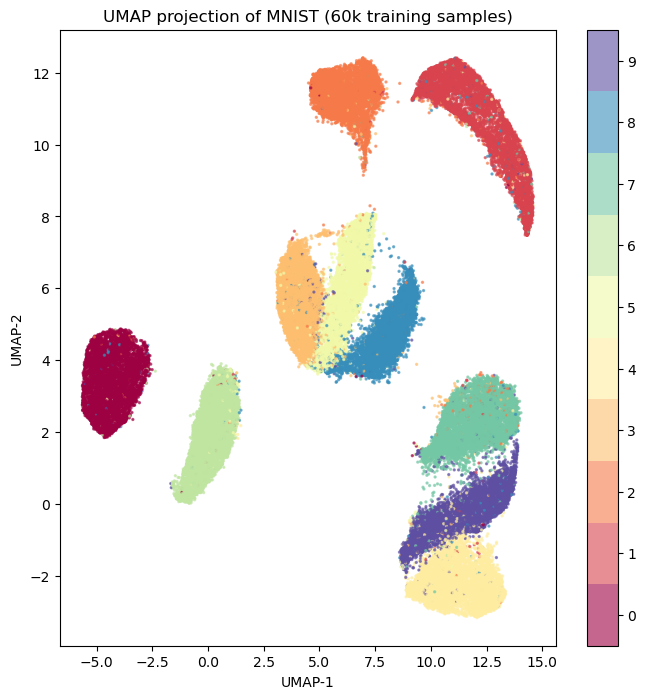

In [6]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import umap
import numpy as np
from tqdm import tqdm

# --- 1. Load MNIST ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])
mnist_train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Convert entire dataset to tensors
X = torch.stack([mnist_train[i][0] for i in tqdm(range(len(mnist_train)), desc="Loading MNIST")])
y = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))])

print(f"Data shape: {X.shape}, Labels shape: {y.shape}")  # Expect (60000, 784)

# --- 2. (Optional) Normalize ---
X = X / X.max()

# --- 3. Run UMAP ---
reducer = umap.UMAP(
    n_neighbors=30,       # local neighborhood size
    min_dist=0.1,         # controls clustering tightness
    n_components=2,       # 2D projection
    metric='euclidean',   # distance metric
    random_state=42
)

embedding = reducer.fit_transform(X.numpy())

print("UMAP embedding shape:", embedding.shape)

# --- 4. Plot ---
plt.figure(figsize=(8, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap="Spectral", s=2, alpha=0.6)
plt.colorbar(scatter, boundaries=np.arange(11)-0.5, ticks=np.arange(10))
plt.title("UMAP projection of MNIST (60k training samples)", fontsize=12)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()



Generated embedding shape: (60000, 2)


/tmp/ipython-input-2370143833.py:36: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 13 Axes> than <Figure size 900x900 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, boundaries=np.arange(11)-0.5, ticks=np.arange(10))


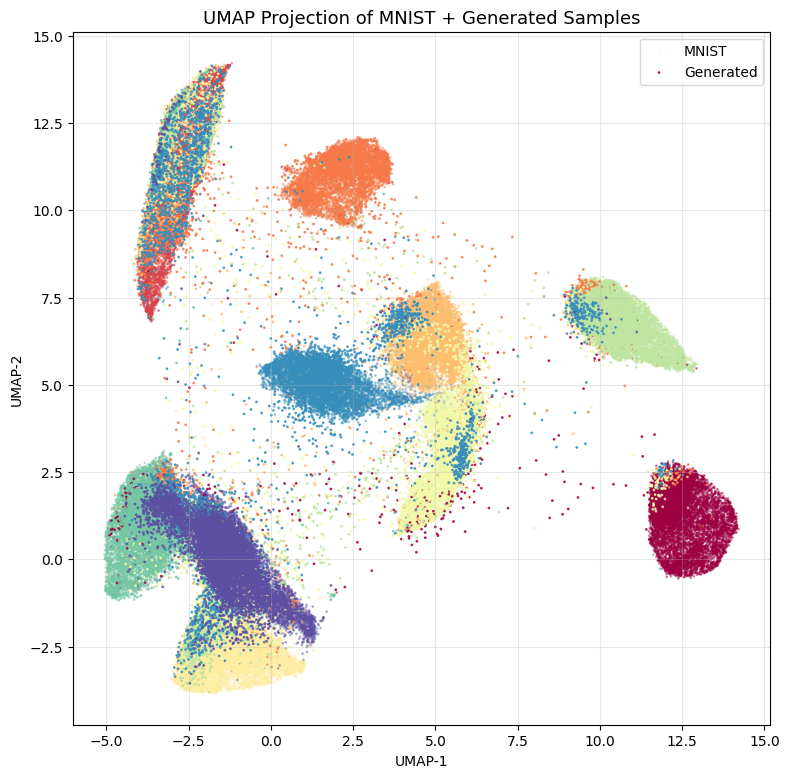

In [190]:
x_final_norm = x_hat_final.clone().detach().cpu()
#x_final_norm = x_final_norm / x_final_norm.max()

mean = mean_pixels.to(device)
std = std_pixels.to(device)
#h_noise = torch.rand(10000, 200, device=device)*2-1
#x_noise_norm = torch.sigmoid(h_noise @ model.V[0].t()).clone().detach().cpu()
#x_noise_norm = (torch.randn(1000, 28*28, device=device) * std + mean).clone().detach().cpu()
#x_noise_norm = (torch.rand(10000, 28*28, device=device) ).clone().detach().cpu()
#x_noise_norm = x_noise / x_noise.max()

embedding_gen = reducer.transform(x_final_norm.numpy())
print("Generated embedding shape:", embedding_gen.shape)
"""embedding_noise = reducer.transform(x_noise_norm.numpy())
print("Noise embedding shape:", embedding_noise.shape)"""

# --- 5. Plot ---
plt.figure(figsize=(9, 9))

# Plot MNIST samples
plt.scatter(embedding[:, 0], embedding[:, 1],
            c=y.cpu(), cmap="Spectral", s=1, alpha=0.4, label="MNIST")

# Plot generated samples (black)
plt.scatter(embedding_gen[:, 0], embedding_gen[:, 1],
            c=y_labels.cpu(), cmap="Spectral", s=1, alpha=0.8, label="Generated")

"""plt.scatter(embedding_noise[:, 0], embedding_noise[:, 1],
            c="red", s=1, alpha=0.8, label="Noise")"""

plt.title("UMAP Projection of MNIST + Generated Samples", fontsize=13)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, boundaries=np.arange(11)-0.5, ticks=np.arange(10))
plt.show()

In [181]:
print(y_labels)

tensor([0, 0, 0,  ..., 9, 9, 9], device='cuda:0')


In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import trange


@torch.no_grad()
def generate_from_noise_with_feedback_and_lateral_multilayer(
    model,
    input_dim=784,
    batch_size=100,
    steps=300,
    alpha=0.9,
    beta_lateral=0.8,
    beta_feedback=0.8,
    tol_y=1e-5,
    device=None,
    use_lateral=True,
    use_feedback=True,
    show_progress=True,
    visualize=True,
    mean_pixels=None,
    std_pixels=None,
    # --- Controller parameters ---
    k_p=2.0,
    alpha_c=0.1,
    dt=0.05,
):
    """
    Multi-layer generation with feedback + lateral dynamics.
    Feedback is mediated through a PI-like controller.

    Forward encoding:
      - At t=0: pure feedforward encoding
      - After t>0: leaky integration of z and h
    """

    if device is None:
        device = next(model.parameters()).device

    # === Initialize noisy inputs ===
    if mean_pixels is not None and std_pixels is not None:
        mean = mean_pixels.to(device)
        std = std_pixels.to(device)
        x = torch.randn(batch_size, input_dim, device=device) * std + mean
    else:
        h_noise = torch.rand(batch_size, 200, device=device) *  - 0.5
        x = torch.sigmoid(h_noise @ model.V[0].t())

    # === Class conditioning (10 samples per class) ===
    num_classes = model.num_classes if hasattr(model, "num_classes") else 10
    y_labels = torch.arange(num_classes, device=device).repeat_interleave(batch_size // num_classes)
    y = F.one_hot(y_labels, num_classes=num_classes).float()

    # === Initialize hidden activations ===
    h_list, z_list, x_hat, y_hat, y_logits = model(x)
    stop_mask = torch.ones(batch_size, device=device)
    loss_history = []

    # === Initialize controller states (for each layer) ===
    u_list = [torch.zeros_like(h) for h in h_list]
    u_int_list = [torch.zeros_like(h) for h in h_list]
    u_output = torch.zeros(batch_size, num_classes, device=device)
    u_int_output = torch.zeros(batch_size, num_classes, device=device)

    iterator = trange(steps, desc="Generating multi-layer samples") if show_progress else range(steps)

    for t in iterator:
        # === Forward encode ===
        h_prev = x
        z_new, h_new = [], []

        for i in range(model.n_layers):
            # Feedforward computation
            z_ff = h_prev @ model.W[i].t()

            # At t == 0: pure feedforward
            if t == 0:
                z_i = z_ff
            else:
                # Leaky integration toward new feedforward drive
                z_i = (1 - dt) * z_list[i] + dt * z_ff

            h_i = model.act(z_i)

            z_new.append(z_i)
            h_new.append(h_i)
            h_prev = h_i

        z_list = [z.clone() for z in z_new]
        h_list = [h.clone() for h in h_new]
        h_list_new = [torch.zeros_like(h) for h in h_list]

        # === Feedback + Lateral integration (top → bottom) ===
        for i in reversed(range(model.n_layers)):
            z_i = z_list[i].clone()
            h_i = h_list[i].clone()

            # --- Feedback integration via controller ---
            if use_feedback:
                if i == model.n_layers - 1:
                    # Top layer feedback from classifier
                    y_logits = h_i @ model.W2.t()
                    y_pred = F.softmax(y_logits, dim=1)

                    error = (y - y_pred)
                    # Controller update (output layer)
                    u_int_next = u_int_output + dt * (error - alpha_c * u_output)
                    u_next = u_int_next + k_p * error
                    delta_fb = u_next @ model.V2.t()

                    # Explicit controller state update
                    u_int_output = u_int_next
                    u_output = u_next

                else:
                    # Hidden layers
                    h_above = h_list_new[i + 1]
                    h_pred_above = h_list[i + 1]
                    error = (h_above - h_pred_above)

                    # Controller update (hidden layer)
                    u_int_next = u_int_list[i + 1] + dt * (error - alpha_c * u_list[i + 1])
                    u_next = u_int_next + k_p * error
                    delta_fb = u_next @ model.V[i + 1].t()

                    # Explicit controller state update
                    u_int_list[i + 1] = u_int_next
                    u_list[i + 1] = u_next

                # Integrate feedback into z
                z_i = z_i + beta_feedback * delta_fb

            # --- Lateral integration ---
            if use_lateral and hasattr(model, "L"):
                z_i_hat = model.act(z_i) @ model.L[i].t()
                delta_lat = z_i_hat - z_i
                z_i = z_i + beta_lateral * delta_lat

            # --- Leaky integration and activation ---
            z_list[i] = (1 - dt) * z_list[i] + dt * z_i # z_list[i] + dt* (- z_list[i] + z_i)
            h_list_new[i] = model.act(z_list[i])

        # === Decode from lowest hidden layer to input ===
        h1_corr = h_list_new[0]
        x_hat = torch.sigmoid(h1_corr @ model.V[0].t())

        h_list = [t.clone() for t in h_list_new]

        # === Input integration ===
        x += alpha * (x_hat - x) * stop_mask[:, None]

        # === Convergence check ===
        y_change = (torch.abs(y_pred - y)).mean(dim=1)
        stop_criterion = (y_change < tol_y)
        stop_mask = (~stop_criterion).float()
        if stop_criterion.all():
            break

        loss = F.mse_loss(x_hat, x).item()
        loss_history.append(loss)
        if show_progress:
            iterator.set_postfix(loss=loss, y_change=y_change.mean().item())

    # === Final results ===
    x_final = x
    x_hat_final = x_hat

    # === Visualization ===
    if visualize:
        samples_per_class = batch_size // num_classes
        x_final_cpu = x_hat_final.detach().cpu()

        plt.figure(figsize=(samples_per_class, num_classes))
        for c in range(num_classes):
            for i in range(samples_per_class):
                idx = c * samples_per_class + i
                plt.subplot(num_classes, samples_per_class, idx + 1)
                plt.imshow(x_final_cpu[idx].view(28, 28), cmap="gray", vmin=0, vmax=1)
                plt.axis("off")
                if i == 0:
                    plt.ylabel(str(c), fontsize=10, rotation=0, labelpad=10)

        plt.suptitle(
            f"Generated Samples with Controller ({model.activation.upper()} activation)\n"
            f"{'Lateral ' if use_lateral else ''}{'Feedback ' if use_feedback else ''}Dynamics",
            fontsize=12,
        )
        plt.tight_layout()
        plt.show()

    print("Generated target labels:", y_labels.tolist())
    print("Predicted labels:", torch.argmax(y_pred, dim=1).tolist())

    return x_final, x_hat_final, loss_history, stop_criterion, y_pred, y_labels


Generating multi-layer samples:  12%|█▏        | 122/1000 [00:00<00:01, 721.91it/s, loss=0.0101, y_change=0.00425]


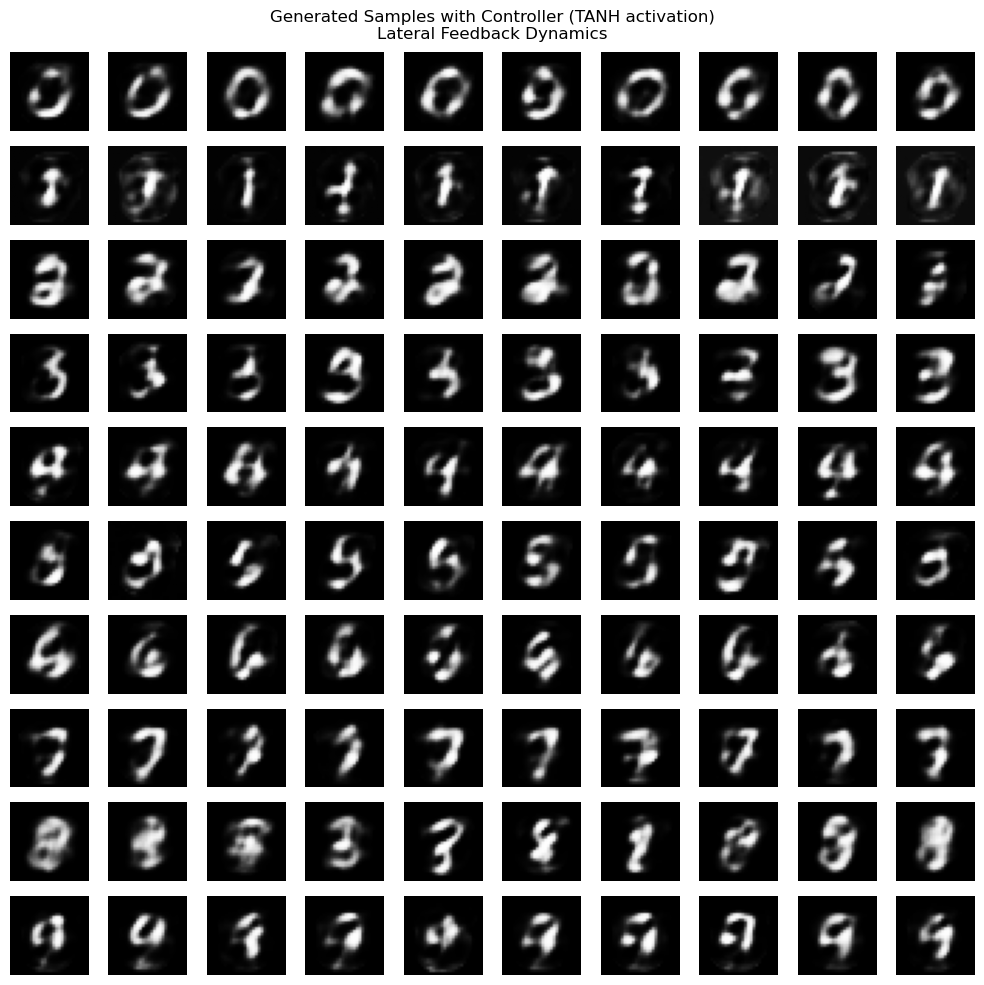

Generated target labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
Predicted labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]


In [10]:
x_final, x_hat_final, loss_history, stop_criterion, y_hat, y_labels = generate_from_noise_with_feedback_and_lateral_multilayer(
    model,
    input_dim=784,
    batch_size=100,
    steps=1000,
    alpha=0.1,
    beta_feedback=1,
    beta_lateral=0.4,
    tol_y=3e-2,
    use_lateral=True,
    use_feedback=True,
    visualize=True,
    mean_pixels=mean_pixels,
    std_pixels=std_pixels,
    k_p= 2.0,
    alpha_c=0.0017
)


In [22]:
np.save("W1.npy", model.W1[0].detach().cpu().numpy())